# Module 1 Computational Problem: GFP Expression Time Course

In this problem I analyze a time series of green fluorescent protein (GFP) fluorescence in *E. coli* after induction at *t* = 0. The data are in `fluorescence_data.csv`, which has two columns: `time_min` and `fluorescence` (in arbitrary units, A.U.).

Tasks: (1) load and inspect the data with NumPy, (2) make a publication-quality figure with Matplotlib, (3) compute the maximum fluorescence, the time of the maximum, the average rate of change between *t* = 10 and 60 min, and the standard deviation over that window, and print them to the screens with clear descriptions (4) add a Markdown section to interpret the plot results and the meaning of calculated metrics in the context of gene expression (5) commit the notebook to a new GitHub repo `module-1-problem` and submit the link to my repository.


## 1. Load the data (NumPy)

I read the CSV with `np.loadtxt`, skip the header row, and split it into `time` and `fluorescence` arrays.


In [2]:
import numpy as np
import matplotlib.pyplot as plt

data = np.loadtxt('fluorescence_data.csv', delimiter=',', skiprows=1)
time = data[:, 0]
fluorescence = data[:, 1]

print(f'Loaded {len(time)} data points, time range {time.min():.0f}-{time.max():.0f} min')
print('First 5 rows:')
for i in range(5):
    print(f'  t={time[i]:.1f} min, F={fluorescence[i]:.1f} A.U.')


Loaded 121 data points, time range 0-120 min
First 5 rows:
  t=0.0 min, F=1.0 A.U.
  t=1.0 min, F=2.0 A.U.
  t=2.0 min, F=0.0 A.U.
  t=3.0 min, F=0.0 A.U.
  t=4.0 min, F=3.0 A.U.


## 2. Plot the time course (Matplotlib)

A publication-quality time series plot with  labeled axes and a informative title. I use a large figure size and a reasonably high `dpi` so the figure stays sharp when embedded in the notebook.


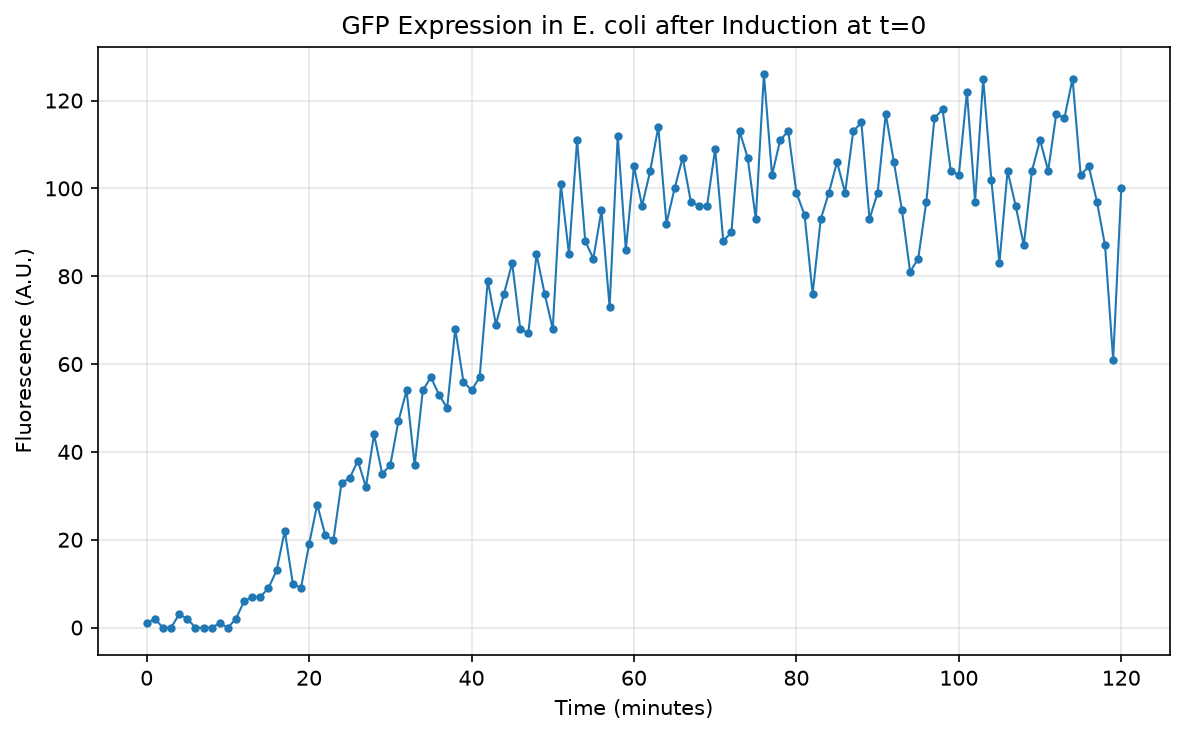

In [3]:
fig, ax = plt.subplots(figsize=(8, 5), dpi=150)
ax.plot(time, fluorescence, marker='o', markersize=3, linestyle='-', linewidth=1, color='#1f77b4')
ax.set_xlabel('Time (minutes)')
ax.set_ylabel('Fluorescence (A.U.)')
ax.set_title('GFP Expression in E. coli after Induction at t=0')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 3. Quantities

- **Maximum fluorescence**: `fluorescence.max()`
- **Time of the maximum**: the index where the maximum is reached
- **Average rate of change, t = 10-60 min**: `(F(60) - F(10)) / (60 - 10)`
- **Standard deviation, t = 10-60 min**: spread of the fluorescence values in that window


In [4]:
# Index and value of the maximum
F_max = fluorescence.max()
indices = np.where(fluorescence == F_max)[0]
t_max_all = time[indices]
t_max = t_max_all[0]

# Select the t = 10-60 min window
mask = (time >= 10) & (time <= 60)
t_win = time[mask]
F_win = fluorescence[mask]

# Average rate: change in F divided by change in t across the window endpoints
avg_rate = (F_win[-1] - F_win[0]) / (t_win[-1] - t_win[0])

# Standard deviation over the window
std_win = F_win.std()

print(f'Maximum fluorescence: {F_max:.2f} A.U.')
print(f'First time reaching maximum: t = {t_max:.1f} min')
print(f'All time points with maximum fluorescence: {t_max_all}')
print(f'Average rate of change (10-60 min): {avg_rate:.3f} A.U./min')
print(f'Standard deviation (10-60 min): {std_win:.3f} A.U.')


Maximum fluorescence: 126.00 A.U.
First time reaching maximum: t = 76.0 min
All time points with maximum fluorescence: [76.]
Average rate of change (10-60 min): 2.100 A.U./min
Standard deviation (10-60 min): 31.135 A.U.


## 4. What the data show

**The curve.** Fluorescence stays near zero for roughly the first 10 minutes after induction, then climbs steadily and roughly saturates around *t* = 60-100 min, where it hovers in the 100-125 A.U. range with some wiggle. The summary table is below.

| Quantity | Value |
|----------|-------|
| Maximum fluorescence | 126 A.U. |
| Time of maximum | 76 min |
| Average rate (10-60 min) | 2.100 A.U./min |
| Std. dev. (10-60 min) | 31.1 A.U. |

The flat beginning makes sense: right after induction there is very little GFP yet, so the signal barely moves. Once expression kicks in the protein accumulates and the curve rises. Over the 10-60 min window the signal goes from about 0 to 105 A.U., which gives an average rate of about 2.1 A.U. per minute.

The standard deviation of 31 A.U. over that window is large, but that is mostly because the trace is climbing the whole time, so the values are spread out over a steep slope rather than scattered about one mean.



## 5. Submission notes
The completed notebook is committed to the GitHub repository `module-1-problem`.
Repository URL: **https://github.com/HaoTianJin-7/module-1-problem**
